# Ćw. 7c Klasyfikacja MNIST z architekturą LSTM
## Traktowanie obrazu jako sekwencji, metoda Many-To-One.
W tym notatniku zobaczymy, jak możemy użyć LSTM jako modelu wiele do jednego, który przyjmuje sekwencję danych i zapewnia pojedyncze wyjście na końcu sekwencji.<br>
Jako przykład wykorzystujemy zbiór danych MNIST i „patchujemy” go, dzieląc obraz na sekwencję łatek i przekazując je do modelu po jednej łatce na raz.
[<img src="https://static.packt-cdn.com/products/9781789346640/graphics/assets/79db1776-f471-4fe6-89b0-67cbae844bfc.png">](LSTM)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader
from torch.utils.data.dataset import Dataset
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch.utils.data.dataloader as dataloader
import torchvision

from tqdm.notebook import trange, tqdm

In [ ]:
# Wymiar mini batches
batch_size = 128

# Liczba epok
num_epochs = 50

# Stała uczenia lr
learning_rate = 1e-4

# Where to load/save the dataset from
data_set_root = "../../datasets"

device = torch.device(0 if torch.cuda.is_available() else 'cpu')

## Create MNIST Dataset and Dataloader

In [ ]:
# Przygotuj złożenie przekształceń obrazów
# transforms.Compose wykona transformacje w kolejności
# UWAGA: niektóre przekształcenia pobierają tylko obraz PIL, inne tylko Tensor
# EG Resize i ToTensor pobierają obraz PIL, Normalize pobiera tensor.
# Patrz dokumentacja
transform = transforms.Compose([
            transforms.Resize(32),
            transforms.ToTensor(),
            transforms.Normalize([0.1307], [0.308])])

# Uwaga: ToTensor() przeskaluje unit8 i dane podobnego typu do float i ponownie przeskaluje do 0-1.
# Uwaga: normalizujemy za pomocą średniej i std zbioru danych.

In [ ]:
# Definicaj zbioru MNIST
# Można wykorzystać także FasionMNIST lub CIFAR10
# https://pytorch.org/docs/stable/torchvision/datasets.html#mnist
train_data = datasets.MNIST(data_set_root, train=True, download=True, transform=transform)
test_data = datasets.MNIST(data_set_root, train=False, download=True, transform=transform)

# Zamierzamy podzielić uczący zbiór danych na zestaw treningowy i walidacyjny 90%/10%.
validation_split = 0.9

# Określ liczbę próbek dla każdego podziału
n_train_examples = int(len(train_data) * validation_split)
n_valid_examples = len(train_data) - n_train_examples

# Funkcja random_split pobierze nasz zbiór danych, podzieli go losowo i da nam zbiór danych
# które są rozmiarami, które mu nadaliśmy
# Uwaga: możemy podzielić go na więcej niż dwie części! W ten sposób utworzyliśmy 3 zbiory.
train_data, valid_data = torch.utils.data.random_split(train_data, [n_train_examples, n_valid_examples],
                                                       generator=torch.Generator().manual_seed(42))

# WAŻNE BY WIEDZIEĆ!!!!!!!!!
# Tutaj przekazujemy funkcji random_split ziarno wprowadzone ręcznie, jest to bardzo ważne, ponieważ jeśli tego nie zrobimy, to
# za każdym razem, gdy losowo podzielimy nasz zestaw treningowy i walidacyjny, otrzymamy różne podziały!!!
# Na przykład, jeśli zapiszemy nasz model i ponownie załadujemy go w przyszłości, zbiór danych, którego teraz używamy do
# będzie zapewne zawierał punkty danych, które początkowo BYŁY w zbiorze walidacyjnym!!!
# Nasz model byłby zatem trenowany zarówno z danymi walidacyjnymi, jak i treningowymi - jest to bardzo źle!!!
# Ustawienie ręcznego seedu na tę samą wartość za każdym razem zapobiega temu!

100%|██████████| 9.91M/9.91M [00:11<00:00, 900kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.80MB/s]


In [ ]:
print(f'Liczba próbek uczących: {len(train_data)}')
print(f'Liczba próbek walidacyjnych: {len(valid_data)}')
print(f'NLiczba próbek testowych: {len(test_data)}')

Number of training examples: 54000
Number of validation examples: 6000
Number of testing examples: 10000


In [ ]:
# Utworzymy zestawy danych szkoleniowych, walidacyjnych i ewaluacyjnych/testowych.
# Najlepszą praktyką jest rozdzielenie danych na te trzy zestawy danych
# Chociaż w zależności od zadania może być potrzebny tylko zestaw Training + Evaluation/Test lub tylko zestaw Training.
# (Zależy to również od ilości posiadanych danych)
# https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataloader
train_loader = dataloader.DataLoader(train_data, shuffle=True, batch_size=batch_size)
valid_loader = dataloader.DataLoader(valid_data, batch_size=batch_size)
test_loader  = dataloader.DataLoader(test_data, batch_size=batch_size)

In [ ]:
# Funkcja przekształcająca partię obrazów w sekwencję łatek

def extract_patches(image_tensor, patch_size=8):
    # Pobieranie wymiarów tensora obrazu
    bs, c, h, w = image_tensor.size()

    # Zdefiniuj warstwę Unfold z odpowiednimi parametrami
    unfold = torch.nn.Unfold(kernel_size=patch_size, stride=patch_size)

    # Zastosowanie Unfold do image_tensor
    unfolded = unfold(image_tensor)

    # Przekształć rozwinięty tensor, aby dopasować go do pożądanego kształtu wyjściowego.
    # Kształt wyjściowy: BSxLxCx8x8, gdzie L jest liczbą łat w każdym wymiarze
    # Dla każdego wymiaru, liczba łat = (oryginalny rozmiar wymiaru) // patch_size
    unfolded = unfolded.transpose(1, 2).reshape(bs, -1, c, patch_size, patch_size)

    return unfolded

In [ ]:
# Utwórz obiekt iterowalny do dataloader
dataiter = next(iter(test_loader))
# Przykład obiektu
test_images, test_labels = dataiter

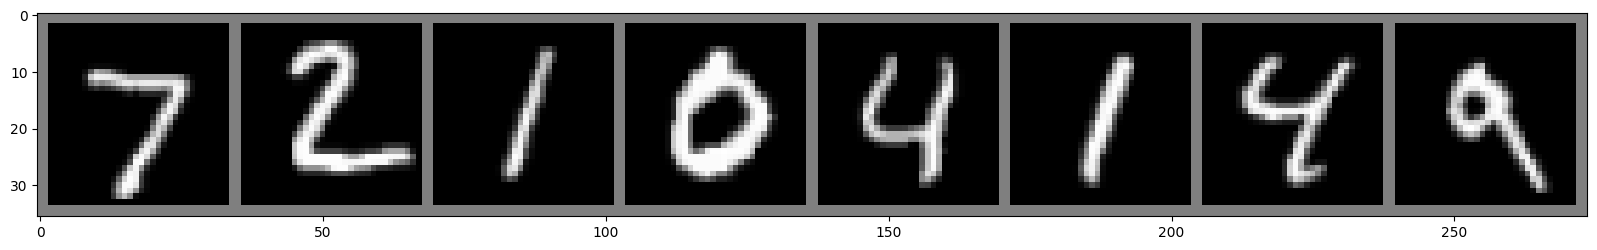

In [ ]:
# Zwizualizujmy całą partię obrazów
plt.figure(figsize = (20,10))
out = torchvision.utils.make_grid(test_images[:8], 8, normalize=True, pad_value=0.5)
_ = plt.imshow(out.numpy().transpose((1, 2, 0)))

Sequence Length 64


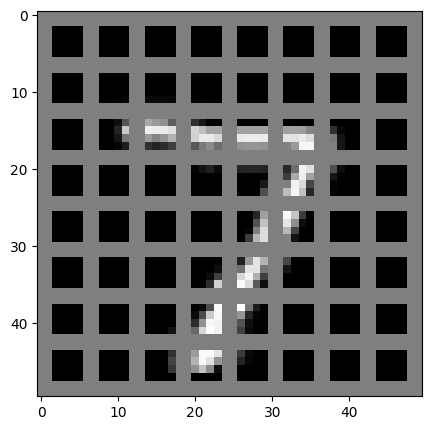

In [ ]:
# Ustaw rozmiar łaty do wyodrębnienia z obrazu
patch_size = 4

# Wyodrębnienie łat z obrazów testowych za pomocą zdefiniowanej funkcji
patches = extract_patches(test_images, patch_size=patch_size)

# Oblicz rozmiar siatki dla wizualizacji
grid_size = test_images.shape[2] // patch_size
print("Sequence Length %d" % (grid_size**2))

# Wizualizacja łat jako siatki
plt.figure(figsize=(5, 5))
out = torchvision.utils.make_grid(patches[0], grid_size, normalize=True, pad_value=0.5)
plt.imshow(out.numpy().transpose((1, 2, 0)))

## Zbudowanie łat obrazu dla LSTM
Ten model wykorzystuje sieć LSTM do sekwencyjnego przetwarzania danych obrazu. Dzieli on obrazy wejściowe na fragmenty, a następnie przekazuje je do warstwy LSTM w celu analizy sekwencyjnej. Bloki resztkowe są włączane do LSTM w celu zwiększenia przepływu gradientu i uchwycenia zależności czasowych. Na koniec dane wyjściowe są przekazywane przez w pełni połączoną warstwę w celu przewidywania.

In [ ]:
# Definiowanie bloku resztkowego dla architektury MLP
class ResBlockMLP(nn.Module):
    def __init__(self, input_size, output_size):
        super(ResBlockMLP, self).__init__()
        # Zdefiniuj normalizację warstwy dla rozmiaru wejścia
        self.norm1 = nn.LayerNorm(input_size)
        # Pierwsza warstwa w pełni połączona
        self.fc1 = nn.Linear(input_size, input_size//2)

        # Normalizacja warstwy dla rozmiaru wejścia // 2
        self.norm2 = nn.LayerNorm(input_size//2)
        # Druga warstwa w pełni połączona
        self.fc2 = nn.Linear(input_size//2, output_size)

        # Ostatnia warstwa w pełni połączona
        self.fc3 = nn.Linear(input_size, output_size)

        # Funkcja aktywacji Exponential Linear Unit (ELU)
        self.act = nn.ELU()

    def forward(self, x):
        # Zastosuj normalizację warstwy i funkcję aktywacji
        x = self.act(self.norm1(x))
        # Obliczanie pominiętego połączenia (skip connection)
        skip = self.fc3(x)

        # Zastosuj normalizację warstwy, w pełni połączoną warstwę i funkcję aktywacji
        x = self.act(self.norm2(self.fc1(x)))
        x = self.fc2(x)

        # Dodaj skip connection
        return x + skip


# Definiowanie modelu LSTM
class LSTM(nn.Module):
    def __init__(self, output_size=10, patch_size=4, lstm_layers=1, hidden_size=64, num_blocks=1):
        super(LSTM, self).__init__()

        # Zdefiniuj w pełni połączoną warstwę dla danych wejściowych
        self.fc_in = nn.Linear(patch_size**2, hidden_size)

        # Zdefiniuj warstwę LSTM
        self.lstm = nn.LSTM(input_size=hidden_size, hidden_size=hidden_size,
                            num_layers=lstm_layers, batch_first=True)

        # Definicja bloków rezydualnych (residual blocks)
        blocks = [ResBlockMLP(hidden_size, hidden_size) for _ in range(num_blocks)]
        self.res_blocks = nn.Sequential(*blocks)

        # Definicja wyjścia warstwy w pełni połączonej
        self.fc_out = nn.Linear(hidden_size, output_size)

        # Funkcja aktywacji
        self.act = nn.ELU()
        self.patch_size = patch_size

    def forward(self, input_data, hidden_in, mem_in):
        # Przekształceni obrazów w sekwencję łat, które będą przekazywane do modelu pojedynczo.
        bs, c, h, w = input_data.shape
        input_seq = extract_patches(input_data, self.patch_size).reshape(bs, -1, self.patch_size**2)

        # Warstwa liniowa przetwarza łatki niezależnie, jak partia
        x = self.act(self.fc_in(input_seq))

        # LSTM będzie przetwarzać sekwencję łat sekwencyjnie
        output, (hidden_out, mem_out) = self.lstm(x, (hidden_in, mem_in))

        # Otrzymamy dane wyjściowe z modelu z każdego kroku czasowego, ale obliczymy tylko stratę w
        # ostatnim kroku czasowym
        x  = self.act(self.res_blocks(output))

        return self.fc_out(x), hidden_out, mem_out

## Budowa Model i uczenie modelu

In [ ]:
# Tworzymy model
# Tworzymy model LSTM do przetwarzania danych MNIST.
# Architektura modelu obejmuje wiele warstw LSTM, a po każdej z nich następują bloki resztkowe w celu ulepszenia funkcji.
# W tym miejscu definiowane są hiperparametry, takie jak rozmiar wyjścia, rozmiar łatki, liczba warstw LSTM i rozmiar ukryty.

# W naszym modelu możemy łączyć ze sobą wiele bloków LSTM
lstm_layers = 3

# Rozmiar ukryty dla warstw LSTM
hidden_size = 32

# Zainicjuj model LSTM ze zdefiniowanymi parametrami i przenieś go na odpowiednie urządzenie (CPU lub GPU).
mnist_lstm = LSTM(output_size=10, patch_size=patch_size,
                  lstm_layers=lstm_layers, hidden_size=hidden_size).to(device)

# Inicjalizacja optymalizatora z powyższymi parametrami
# Używamy optymalizatora Adam do trenowania modelu z określonym współczynnikiem uczenia się.
optimizer = optim.Adam(mnist_lstm.parameters(), lr=learning_rate)

# Definicja funkcji straty
# W przypadku zadań klasyfikacyjnych, takich jak rozpoznawanie cyfr MNIST, stosujemy stratę entropii krzyżowej jako funkcję straty.
loss_fn = nn.CrossEntropyLoss()

# Inicjalizacja treningowych i walidacyjnych rejestratorów strat i dokładności
training_loss_logger = []
training_acc_logger = []
valid_loss_logger = []
valid_acc_logger = []

In [ ]:
# Sprawdzenie liczby parametrów modelu
num_model_params = 0
for param in mnist_lstm.parameters():
    num_model_params += param.flatten().shape[0]

print("-Ten model ma %d (Approximately %d Million) parametrów!" % (num_model_params, num_model_params//1e6))

-This Model Has 28442 (Approximately 0 Million) Parameters!


## Uczenie

In [ ]:
# Uczenie
train_acc = 0
valid_acc = 0

# Zainicjuj pasek postępu, aby śledzić epoki i wyświetlać dokładność uczenia i walidacji.
pbar = trange(0, num_epochs, leave=False, desc="Epoch")
for epoch in pbar:
    # Zaktualizuj pasek postępu z bieżącymi dokładnościami treningu i walidacji.
    pbar.set_postfix_str('Accuracy: Train %.2f%%, Val %.2f%%' % (train_acc * 100, valid_acc * 100))

    # Ustawienie modelu w tryb uczenia
    mnist_lstm.train()
    train_acc = 0

    # Iteracja przez dataloader dla danych uczących
    for data, label in tqdm(train_loader, desc="Training", leave=False):
        # Przenoszenie danych i etykiet do odpowiedniego urządzenia
        data = data.to(device)
        label = label.to(device)

        # Inicjalizacja stanów ukrytych i buforów pamięci zerami
        hidden = torch.zeros(lstm_layers, data.shape[0], hidden_size, device=device)
        memory = torch.zeros(lstm_layers, data.shape[0], hidden_size, device=device)

        # Propagacja w przód
        data_pred, hidden, memory = mnist_lstm(data, hidden, memory)

        # Wybierz dane wyjściowe z ostatniego kroku czasowego do obliczenia straty
        last_target = data_pred[:, -1, :]

        # Obliczenie straty
        loss = loss_fn(last_target, label)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Rejestrowanie strat treningowych i obliczanie dokładności treningu
        training_loss_logger.append(loss.item())
        train_acc += (last_target.argmax(1) == label).sum()

    # Obliczanie i rejestrowanie dokładności treningu
    train_acc = (train_acc/len(train_data)).item()
    training_acc_logger.append(train_acc)

    # Tryb oceny
    mnist_lstm.eval()
    valid_acc = 0

    # Ocena
    with torch.no_grad():
        # Iteracja przez dataloader dla danych walidacji
        for data, label in tqdm(valid_loader, desc="Validation", leave=False):
            # Move data and labels to the appropriate device
            data = data.to(device)
            label = label.to(device)

            # Inicjalizacja stanów ukrytych i buforów pamięci zerami
            hidden = torch.zeros(lstm_layers, data.shape[0], hidden_size, device=device)
            memory = torch.zeros(lstm_layers, data.shape[0], hidden_size, device=device)

            #Propagacja w przód
            data_pred, hidden, memory = mnist_lstm(data, hidden, memory)

            # Wybierz dane wyjściowe z ostatniego kroku czasowego do obliczenia straty
            last_target = data_pred[:, -1, :]

            # Obliczenie starty
            loss = loss_fn(last_target, label)

            # Rejestrowanie strat walidacji i obliczanie dokładności walidacji
            valid_loss_logger.append(loss.item())
            valid_acc += (last_target.argmax(1) == label).sum()

    # Obliczanie i rejestrowanie dokładności walidacji
    valid_acc = (valid_acc/len(valid_data)).item()
    valid_acc_logger.append(valid_acc)

Epoch:   0%|          | 0/50 [00:00<?, ?it/s]

Training:   0%|          | 0/422 [00:00<?, ?it/s]

Validation:   0%|          | 0/47 [00:00<?, ?it/s]

Training:   0%|          | 0/422 [00:00<?, ?it/s]

Validation:   0%|          | 0/47 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/47 [00:00<?, ?it/s]

Training:   0%|          | 0/422 [00:00<?, ?it/s]

Validation:   0%|          | 0/47 [00:00<?, ?it/s]

Training:   0%|          | 0/422 [00:00<?, ?it/s]

Validation:   0%|          | 0/47 [00:00<?, ?it/s]

## Wykresy miar wykonania

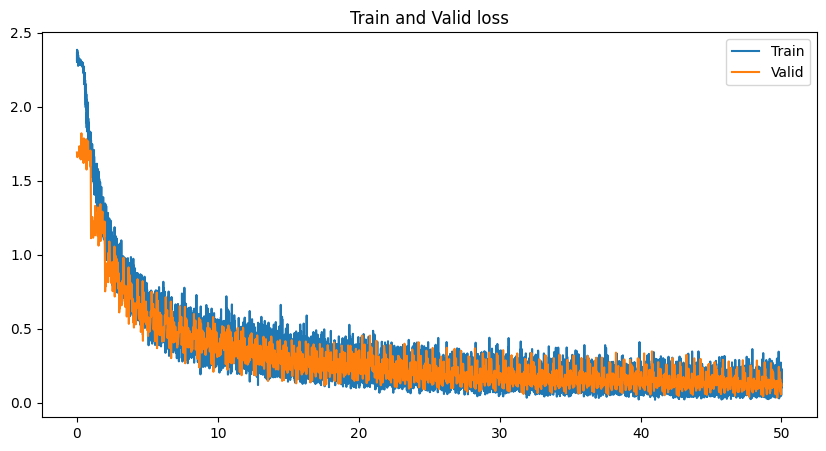

In [ ]:
plt.figure(figsize=(10, 5))
plt.title("Strata uczenia i walidacji")
plt.plot(np.linspace(0, num_epochs, len(training_loss_logger)), training_loss_logger)
plt.plot(np.linspace(0, num_epochs, len(valid_loss_logger)), valid_loss_logger)
plt.legend(["Uczenie", "Walidacja"])

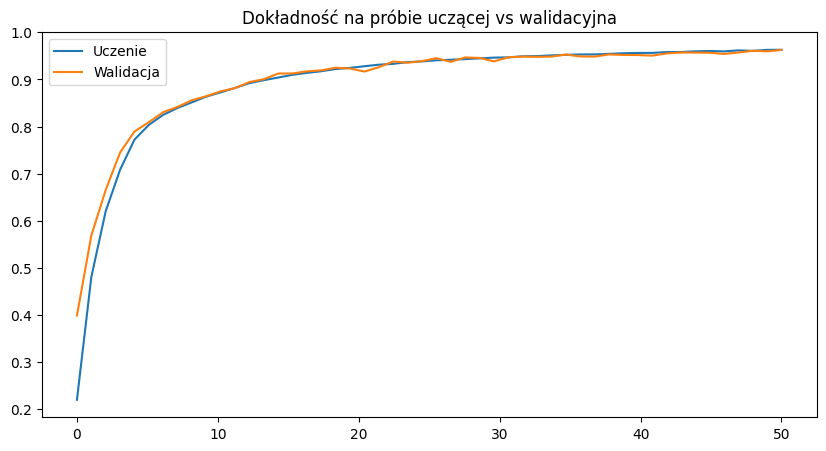

In [ ]:
plt.figure(figsize=(10, 5))
plt.title("Dokładność na próbie uczącej vs walidacyjna")
plt.plot(np.linspace(0, num_epochs, len(training_acc_logger)), training_acc_logger)
plt.plot(np.linspace(0, num_epochs, len(valid_acc_logger)), valid_acc_logger)
plt.legend(["Uczenie", "Walidacja"])

## Testing

In [ ]:
mnist_lstm.eval()
test_acc = 0
with torch.no_grad():
    for data, label in tqdm(test_loader, desc="Testing", leave=False):
        data = data.to(device)
        label = label.to(device)

        hidden = torch.zeros(lstm_layers, data.shape[0], hidden_size, device=device)
        memory = torch.zeros(lstm_layers, data.shape[0], hidden_size, device=device)

        data_pred, hidden, memory = mnist_lstm(data, hidden, memory)
        last_target = data_pred[:, -1, :]

        test_acc += (last_target.argmax(1) == label).sum()
test_acc = (test_acc/len(test_data)).item()

print("Test Accuracy %.2f%%" % (test_acc * 100))

Testing:   0%|          | 0/79 [00:00<?, ?it/s]

Test Accuracy 96.42%
